In [67]:
import pandas as pd
import seaborn as sns
import numpy as np


In [68]:
 df=sns.load_dataset("titanic")
 df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [70]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [71]:
df.shape

(891, 15)

In [72]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [73]:
print(df.columns)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [74]:
# columns_titanic=['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
#        'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
#        'alive', 'alone']
# for i in columns_titanic:
#     if df[i].isnull().sum()!=0:
#       percentage=(df[i].isnull().sum()/df.shape[0])*100
#       print("column_name:",i,"****","percentage of null values each column:",percentage)
#       if percentage<=5:
#         df=df.dropna(subset=[i])
#       elif percentage>5 and percentage<=30:
#         df=df.fillna(df[i].mean())
#       else:
        # df=df.drop(columns=[i])



In [75]:
columns_titanic = [
    'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
    'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
    'alive', 'alone'
]

for i in columns_titanic:

    if df[i].isnull().sum() != 0:

        percentage = (df[i].isnull().sum() / df.shape[0]) * 100

        print("Column:", i)
        print("Missing percentage:", percentage)

        if percentage <= 5:
            df = df.dropna(subset=[i])
            print("Action: Dropped rows")

        elif percentage <= 30:

            if df[i].dtype == 'object':
                df[i] = df[i].fillna(df[i].mode()[0])
                print("Action: Filled with mode")
            else:
                df[i] = df[i].fillna(df[i].mean())
                print("Action: Filled with mean")

        else:
            df = df.drop(columns=[i])
            print("Action: Dropped column")

        print("-" * 50)

print("Final shape:", df.shape)

Column: age
Missing percentage: 19.865319865319865
Action: Filled with mean
--------------------------------------------------
Column: embarked
Missing percentage: 0.22446689113355783
Action: Dropped rows
--------------------------------------------------
Column: deck
Missing percentage: 77.39032620922384
Action: Dropped column
--------------------------------------------------
Final shape: (889, 14)


In [76]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [77]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [78]:
df["sex"] = df["sex"].replace("male", 1).replace("female", 0)
df["alive"]=df["alive"].replace("yes",1).replace("no",0)
df=pd.get_dummies(df,columns=["embark_town","class","embarked","who"],drop_first="True")
df.columns

/tmp/ipykernel_2503/2473860697.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sex"] = df["sex"].replace("male", 1).replace("female", 0)
/tmp/ipykernel_2503/2473860697.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["alive"]=df["alive"].replace("yes",1).replace("no",0)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'adult_male', 'alive', 'alone', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class_Second', 'class_Third', 'embarked_Q',
       'embarked_S', 'who_man', 'who_woman'],
      dtype='object')

In [79]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.dtypes)

(889, 18)
survived                   0
pclass                     0
sex                        0
age                        0
sibsp                      0
parch                      0
fare                       0
adult_male                 0
alive                      0
alone                      0
embark_town_Queenstown     0
embark_town_Southampton    0
class_Second               0
class_Third                0
embarked_Q                 0
embarked_S                 0
who_man                    0
who_woman                  0
dtype: int64
111
survived                     int64
pclass                       int64
sex                          int64
age                        float64
sibsp                        int64
parch                        int64
fare                       float64
adult_male                    bool
alive                        int64
alone                         bool
embark_town_Queenstown        bool
embark_town_Southampton       bool
class_Second                  b

In [80]:
df.to_csv("titanic_cleaned.csv", index=False)
from google.colab import files
files.download("titanic_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
# Question 3 — Study age and fare

# You need to analyze two columns:
# age
# fare
# Make:
# Histogram for age
# Box plot for age
# Histogram for fare
# Box plot for fare
# Then:
# Find outliers using the IQR method.
# Count the outliers in age.
# Count the outliers in fare.
# For fare, calculate:
# Mean
# Median
# Mode
# Decide whether fare is:
# Right-skewed
# Left-skewed
# Symmetric
# Simple meaning:
# 👉 Understand the distribution of age and ticket fare and find unusual values

In [82]:
#  Find outliers using the IQR method.
# Count the outliers in age.
# Count the outliers in fare.
print("column_age")
print(df["age"].describe())
print("*"*30)
print("column_fare")
print(df["fare"].describe())


column_age
count    889.000000
mean      29.653446
std       12.968366
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: age, dtype: float64
******************************
column_fare
count    889.000000
mean      32.096681
std       49.697504
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


In [83]:
# Function to find outliers using IQR
def find_outliers( column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))
    print("-" * 40)


# Count age outliers
find_outliers('age')

# Count fare outliers
find_outliers('fare')

Column: age
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower limit: 2.5
Upper limit: 54.5
Number of outliers: 65
----------------------------------------
Column: fare
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower limit: -26.7605
Upper limit: 65.6563
Number of outliers: 114
----------------------------------------


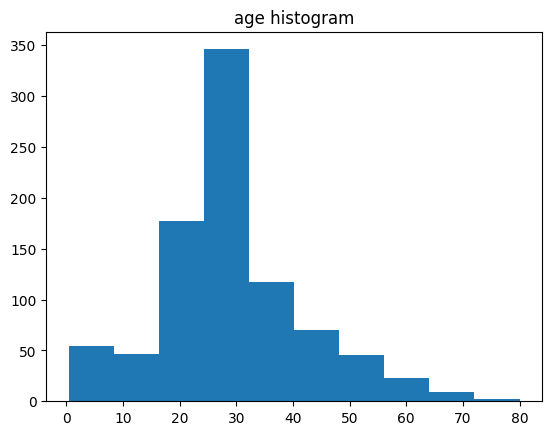

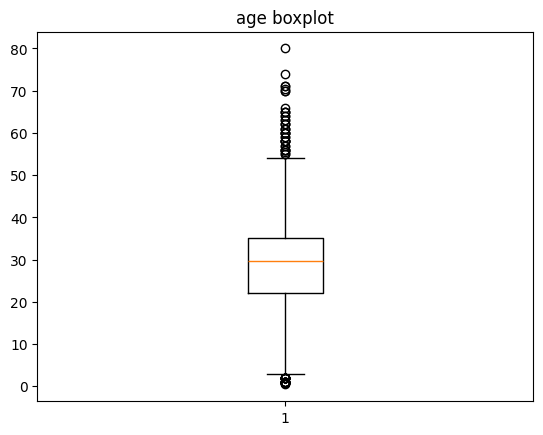

In [84]:
from matplotlib import pyplot as plt
import seaborn as sns
x=df["age"]
y=df["fare"]
plt.title("age histogram")
plt.hist(x)
plt.show()

plt.title("age boxplot")
plt.boxplot(x)
plt.show()


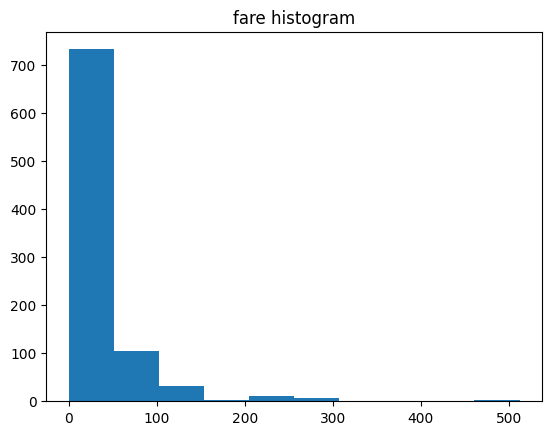

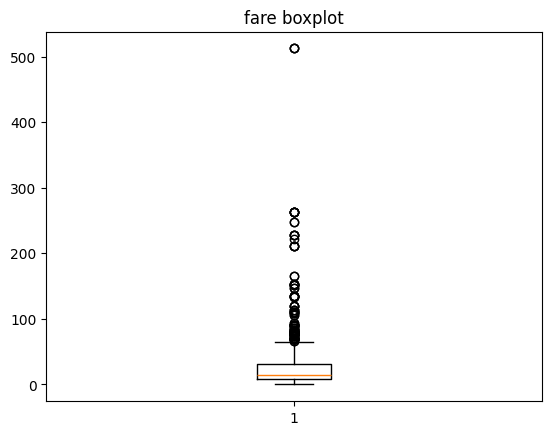

In [85]:
plt.title("fare histogram")
plt.hist(y)
plt.show()
plt.title("fare boxplot")
plt.boxplot(y)
plt.show()


In [86]:
# Calculate mean, median and mode
mean = df['fare'].mean()
median = df['fare'].median()
mode = df['fare'].mode()[0]

print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

# Decide skewness
if mean > median > mode:
    print("Fare is Right-skewed")
elif mean < median < mode:
    print("Fare is Left-skewed")
else:
    print("Fare is approximately Symmetric")

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Fare is Right-skewed


Survival Rate by Sex:
sex
0    0.740385
1    0.188908
Name: survived, dtype: float64

Survival Rate by Pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival Rate by Sex and Pclass:
sex  pclass
0    1         0.967391
     2         0.921053
     3         0.500000
1    1         0.368852
     2         0.157407
     3         0.135447
Name: survived, dtype: float64

Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.074673 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.327954  0.081656  0.016824 -0.548193
age      -0.074673 -0.327954  1.000000 -0.231875 -0.178232  0.088604
sibsp    -0.034040  0.081656 -0.231875  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.178232  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.088604  0.160887  0.217532  1.000000



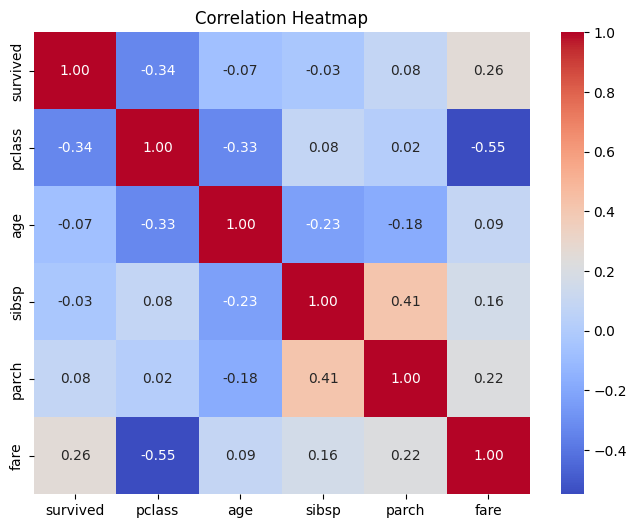

Two Strongest Correlations:
fare   pclass   -0.548193
parch  sibsp     0.414542
dtype: float64


In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Survival rate by SEX
# ==========================================

sex_survival = df.groupby('sex')['survived'].mean()

print("Survival Rate by Sex:")
print(sex_survival)
print()


# ==========================================
# 2. Survival rate by PCLASS
# ==========================================

pclass_survival = df.groupby('pclass')['survived'].mean()

print("Survival Rate by Pclass:")
print(pclass_survival)
print()


# ==========================================
# 3. Survival rate by SEX + PCLASS
# ==========================================

sex_pclass_survival = df.groupby(
    ['sex', 'pclass']
)['survived'].mean()

print("Survival Rate by Sex and Pclass:")
print(sex_pclass_survival)
print()


# ==========================================
# 4. Correlation Matrix
# ==========================================

columns = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

corr = df[columns].corr()

print("Correlation Matrix:")
print(corr)
print()


# ==========================================
# 5. Correlation Heatmap
# ==========================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


# ==========================================
# 6. Find Two Strongest Correlations
# ==========================================

# Make a copy
corr_copy = corr.copy()

# Remove diagonal values
np.fill_diagonal(corr_copy.values, np.nan)

# Get all correlation pairs
corr_pairs = corr_copy.unstack()

# Remove duplicate pairs
corr_pairs = corr_pairs.dropna()

# Keep only one pair from each combination
corr_pairs = corr_pairs[
    [(i < j) for i, j in corr_pairs.index]
]

# Sort by absolute correlation value
strongest = corr_pairs.reindex(
    corr_pairs.abs().sort_values(ascending=False).index
)

print("Two Strongest Correlations:")
print(strongest.head(2))

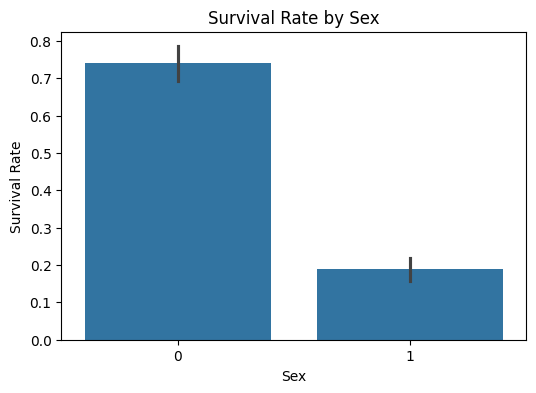

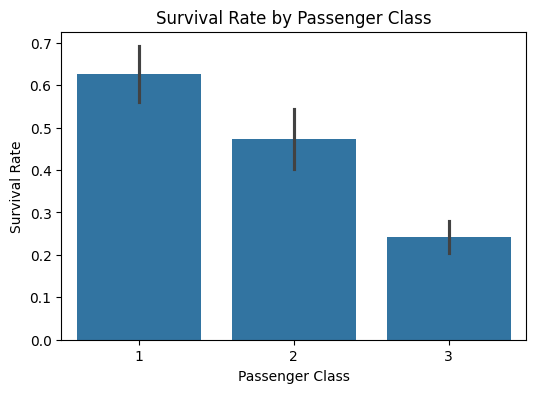

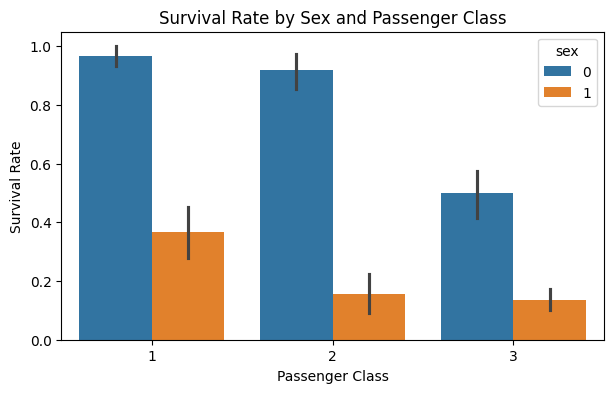

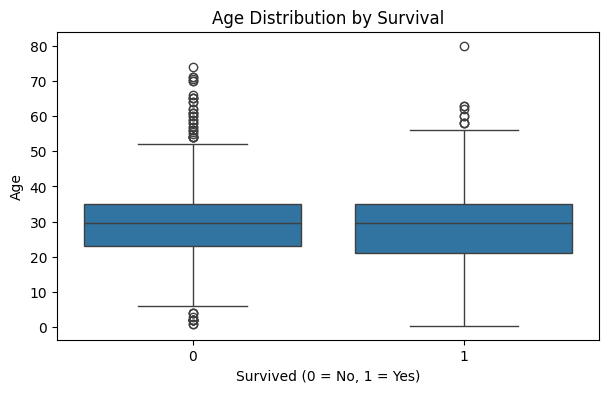

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CHART 1: Survival by Sex
# ==========================================

plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x='sex',
    y='survived'
)

plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.xlabel('Sex')
plt.show()


# ==========================================
# CHART 2: Survival by Passenger Class
# ==========================================

plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x='pclass',
    y='survived'
)

plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.show()


# ==========================================
# CHART 3: Survival by Sex and Passenger Class
# ==========================================

plt.figure(figsize=(7, 4))

sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    hue='sex'
)

plt.title('Survival Rate by Sex and Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.show()


# ==========================================
# CHART 4: Age Distribution by Survival
# ==========================================

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x='survived',
    y='age'
)

plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

In [89]:
# Question 6 — Standardization
# You need to standardize:
# - age
# - fare
# Using the idea:
# z = (x − mean) / standard deviation
# After standardization, check whether:
# - Mean is approximately 0
# - Standard deviation is approximately 1
# Show the result before and after standardization.


from sklearn.preprocessing import StandardScaler

# Before standardization
print("BEFORE STANDARDIZATION")
print("Age - Mean:", df["age"].mean())
print("Age - Std:", df["age"].std())

print("Fare - Mean:", df["fare"].mean())
print("Fare - Std:", df["fare"].std())

# Standardize age and fare
scaler = StandardScaler()

df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

# After standardization
print("\nAFTER STANDARDIZATION")
print("Age - Mean:", df["age"].mean())
print("Age - Std:", df["age"].std())

print("Fare - Mean:", df["fare"].mean())
print("Fare - Std:", df["fare"].std())


BEFORE STANDARDIZATION
Age - Mean: 29.65344637067425
Age - Std: 12.968366309252332
Fare - Mean: 32.09668087739032
Fare - Std: 49.69750431670801

AFTER STANDARDIZATION
Age - Mean: 3.3169317811073295e-16
Age - Std: 1.0005629046322482
Fare - Mean: 1.3987061727561027e-16
Fare - Std: 1.0005629046322495


In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, confusion_matrix,
    recall_score, f1_score, roc_auc_score, roc_curve
)
import numpy as np
import pandas as pd
df=pd.read_csv("/content/titanic_cleaned.csv")
x=df.drop(columns=['survived',"alive"])
y=df["survived"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression()
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)
x_train_pred=model.fit(x_train_scale,y_train)
y_pred=model.predict(x_test_scale)
logistic_reg_Accuracy=round(accuracy_score(y_test, y_pred), 3),
logistic_reg_Precision=round(precision_score(y_test, y_pred), 3),
logistic_reg_Recall=round(recall_score(y_test, y_pred), 3),
logistic_reg_F1=round(f1_score(y_test, y_pred), 3),
logistic_reg_CM=confusion_matrix(y_test, y_pred),
logistic_reg_AUC=round(roc_auc_score(y_test, y_pred), 3),
logistic_reg_ROC=roc_curve(y_test, y_pred)
print("logistic_reg_Accuracy",logistic_reg_Accuracy)
print("logistic_reg_Precision",logistic_reg_Precision)
print("logistic_reg_Recall",logistic_reg_Recall)
print("logistic_reg_F1",logistic_reg_F1)
print("logistic_reg_CM",logistic_reg_CM)
print("logistic_reg_AUC",logistic_reg_AUC)
print("logistic_reg_ROC",logistic_reg_ROC)


logistic_reg_Accuracy (0.815,)
logistic_reg_Precision (0.743,)
logistic_reg_Recall (0.797,)
logistic_reg_F1 (0.769,)
logistic_reg_CM (array([[90, 19],
       [14, 55]]),)
logistic_reg_AUC (np.float64(0.811),)
logistic_reg_ROC (array([0.        , 0.17431193, 1.        ]), array([0.        , 0.79710145, 1.        ]), array([inf,  1.,  0.]))


In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,ConfusionMatrixDisplay,recall_score,f1_score,auc
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/titanic_cleaned.csv")
x=df.drop(columns=["survived","alive"])
y=df["survived"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
for depth in [2, 3, 4, 5, 6, 7, 8, 10]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=2,
        min_samples_split=4,
        random_state=42
    )
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("depth",depth)
    decision_tree_Accuracy=round(accuracy_score(y_test, y_pred), 3),
    decision_tree_Precision=round(precision_score(y_test, y_pred), 3),
    decision_tree_Recall=round(recall_score(y_test, y_pred), 3),
    decision_tree_F1=round(f1_score(y_test, y_pred), 3),
    decision_tree_CM=confusion_matrix(y_test, y_pred),
    decision_tree_AUC=round(roc_auc_score(y_test, y_pred), 3),
    decision_tree_ROC=roc_curve(y_test, y_pred)
    print("decision_tree_Accuracy",logistic_reg_Accuracy)
    print("decision_tree_Precision",logistic_reg_Precision)
    print("decision_tree_Recall",logistic_reg_Recall)
    print("decision_tree_F1",logistic_reg_F1)
    print("decision_tree_CM",logistic_reg_CM)
    print("decision_tree_AUC",logistic_reg_AUC)
    print("decision_tree_ROC",logistic_reg_ROC)


depth 2
decision_tree_Accuracy (0.815,)
decision_tree_Precision (0.743,)
decision_tree_Recall (0.797,)
decision_tree_F1 (0.769,)
decision_tree_CM (array([[90, 19],
       [14, 55]]),)
decision_tree_AUC (np.float64(0.811),)
decision_tree_ROC (array([0.        , 0.17431193, 1.        ]), array([0.        , 0.79710145, 1.        ]), array([inf,  1.,  0.]))
depth 3
decision_tree_Accuracy (0.815,)
decision_tree_Precision (0.743,)
decision_tree_Recall (0.797,)
decision_tree_F1 (0.769,)
decision_tree_CM (array([[90, 19],
       [14, 55]]),)
decision_tree_AUC (np.float64(0.811),)
decision_tree_ROC (array([0.        , 0.17431193, 1.        ]), array([0.        , 0.79710145, 1.        ]), array([inf,  1.,  0.]))
depth 4
decision_tree_Accuracy (0.815,)
decision_tree_Precision (0.743,)
decision_tree_Recall (0.797,)
decision_tree_F1 (0.769,)
decision_tree_CM (array([[90, 19],
       [14, 55]]),)
decision_tree_AUC (np.float64(0.811),)
decision_tree_ROC (array([0.        , 0.17431193, 1.        ]), a

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,ConfusionMatrixDisplay,recall_score,f1_score,auc
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/titanic_cleaned.csv")
x=df.drop(columns=["survived","alive"])
y=df["survived"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
for depth in [2, 3, 4, 5, 6, 7, 8, 10]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=2,
        min_samples_split=4,
        random_state=42
    )
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

In [93]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'adult_male', 'alive', 'alone', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class_Second', 'class_Third', 'embarked_Q',
       'embarked_S', 'who_man', 'who_woman'],
      dtype='object')

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    confusion_matrix,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/titanic_cleaned.csv")

x = df.drop(columns=["survived", "alive"])
y = df["survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

for n in [50, 100, 150, 200]:

    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=6,
        min_samples_leaf=2,
        min_samples_split=4,
        random_state=42
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    # Probability of class 1
    random_for_Accuracy=round(accuracy_score(y_test, y_pred), 3),
    random_for_Precision=round(precision_score(y_test, y_pred), 3),
    random_for_Recall=round(recall_score(y_test, y_pred), 3),
    random_for_F1=round(f1_score(y_test, y_pred), 3),
    random_for_tree_CM=confusion_matrix(y_test, y_pred),
    random_for_AUC=round(roc_auc_score(y_test, y_pred), 3),
    random_for_ROC=roc_curve(y_test, y_pred)


    print(
        "n_estimators:", n,
        "Accuracy:", round(accuracy_score(y_test, y_pred), 3),
        "Precision:", round(precision_score(y_test, y_pred), 3),
        "Recall:", round(recall_score(y_test, y_pred), 3),
        "F1:", round(f1_score(y_test, y_pred), 3),
        "CM:", confusion_matrix(y_test, y_pred),
        "AUC:", round(roc_auc_score(y_test, y_pred), 3),
        "ROC:", roc_curve(y_test, y_pred)
    )

n_estimators: 50 Accuracy: 0.826 Precision: 0.863 Recall: 0.647 F1: 0.739 CM: [[103   7]
 [ 24  44]] AUC: 0.792 ROC: (array([0.        , 0.06363636, 1.        ]), array([0.        , 0.64705882, 1.        ]), array([inf,  1.,  0.]))
n_estimators: 100 Accuracy: 0.831 Precision: 0.88 Recall: 0.647 F1: 0.746 CM: [[104   6]
 [ 24  44]] AUC: 0.796 ROC: (array([0.        , 0.05454545, 1.        ]), array([0.        , 0.64705882, 1.        ]), array([inf,  1.,  0.]))
n_estimators: 150 Accuracy: 0.826 Precision: 0.863 Recall: 0.647 F1: 0.739 CM: [[103   7]
 [ 24  44]] AUC: 0.792 ROC: (array([0.        , 0.06363636, 1.        ]), array([0.        , 0.64705882, 1.        ]), array([inf,  1.,  0.]))
n_estimators: 200 Accuracy: 0.826 Precision: 0.863 Recall: 0.647 F1: 0.739 CM: [[103   7]
 [ 24  44]] AUC: 0.792 ROC: (array([0.        , 0.06363636, 1.        ]), array([0.        , 0.64705882, 1.        ]), array([inf,  1.,  0.]))


In [95]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE


# --------------------------------------------------
# 1. Load data
# --------------------------------------------------

df = pd.read_csv("/content/titanic_cleaned.csv")

# Remove target and data leakage column
x = df.drop(columns=["survived", "alive"])
y = df["survived"]


# --------------------------------------------------
# 2. Check class distribution
# --------------------------------------------------

print("Did not survive (0):", (y == 0).sum())
print("Survived (1):", (y == 1).sum())

print("Did not survive %:", round((y == 0).sum() / len(y) * 100, 2))
print("Survived %:", round((y == 1).sum() / len(y) * 100, 2))


# --------------------------------------------------
# 3. Train-test split
# --------------------------------------------------

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 4. Scaling
# --------------------------------------------------

scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)


# --------------------------------------------------
# 5. NORMAL / BASELINE MODEL
# --------------------------------------------------

model = LogisticRegression(max_iter=1000)

model.fit(x_train_scale, y_train)

y_pred = model.predict(x_test_scale)

baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)


# --------------------------------------------------
# 6. CLASS_WEIGHT = BALANCED
# --------------------------------------------------

model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_balanced.fit(x_train_scale, y_train)

y_pred_balanced = model_balanced.predict(x_test_scale)

balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)


# --------------------------------------------------
# 7. SMOTE
# --------------------------------------------------

smote = SMOTE(random_state=42)

# IMPORTANT: SMOTE ONLY on training data
x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scale,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(x_train_smote, y_train_smote)

# Test data remains untouched
y_pred_smote = model_smote.predict(x_test_scale)

smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)


# --------------------------------------------------
# 8. Compare all three methods
# --------------------------------------------------

print("\n========== RESULTS ==========")

print("\nBaseline:")
print("Precision:", round(baseline_precision, 3))
print("Recall:", round(baseline_recall, 3))
print("F1 Score:", round(baseline_f1, 3))

print("\nClass Weight Balanced:")
print("Precision:", round(balanced_precision, 3))
print("Recall:", round(balanced_recall, 3))
print("F1 Score:", round(balanced_f1, 3))

print("\nSMOTE:")
print("Precision:", round(smote_precision, 3))
print("Recall:", round(smote_recall, 3))
print("F1 Score:", round(smote_f1, 3))

Did not survive (0): 549
Survived (1): 340
Did not survive %: 61.75
Survived %: 38.25

Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

========== RESULTS ==========

Baseline:
Precision: 0.797
Recall: 0.691
F1 Score: 0.74

Class Weight Balanced:
Precision: 0.779
Recall: 0.779
F1 Score: 0.779

SMOTE:
Precision: 0.781
Recall: 0.735
F1 Score: 0.758


In [96]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 1. Load data
df = pd.read_csv("/content/titanic_cleaned.csv")

# Remove target and data leakage column
x = df.drop(columns=["survived", "alive"])
y = df["survived"]


# 2. Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 3. Random Forest
rf = RandomForestClassifier(
    random_state=42,
    oob_score=True
)


# 4. Parameters to tune
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10],
    "max_features": ["sqrt", "log2"]
}


# 5. GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


# 6. Train GridSearch
grid_search.fit(x_train, y_train)


# 7. Best parameters
print("Best Parameters:")
print(grid_search.best_params_)


# 8. Best CV score
print("Best CV F1 Score:", round(grid_search.best_score_, 3))


# 9. Best model
best_model = grid_search.best_estimator_


# 10. Test prediction
y_pred = best_model.predict(x_test)


# 11. Test metrics
print("\nTest Results:")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1 Score :", round(f1_score(y_test, y_pred), 3))


# 12. OOB Score
print("OOB Score:", round(best_model.oob_score_, 3))

Best Parameters:
{'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV F1 Score: 0.757

Test Results:
Accuracy : 0.809
Precision: 0.804
Recall   : 0.662
F1 Score : 0.726
OOB Score: 0.819


In [97]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'adult_male', 'alive', 'alone', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class_Second', 'class_Third', 'embarked_Q',
       'embarked_S', 'who_man', 'who_woman'],
      dtype='object')

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/titanic_cleaned.csv")

x = df.drop(columns="fare")
y = df["fare"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LinearRegression()

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 18.391975984131545
RMSE: 41.307349111467
R2: 0.3604448570166623


In [99]:
df["fare"].describe()

,fare
count,889.000000
mean,32.096681
std,49.697504
min,0.000000
25%,7.895800
50%,14.454200
75%,31.000000
max,512.329200


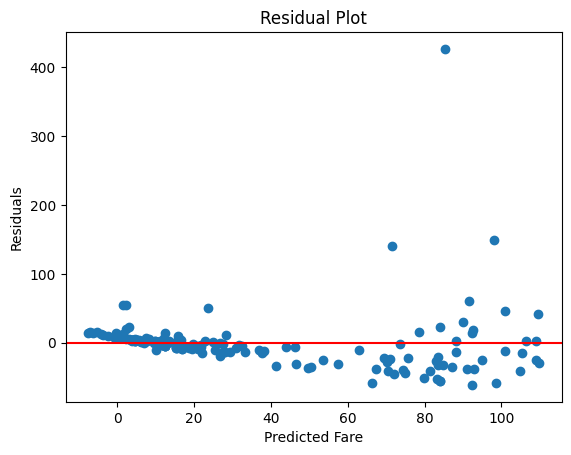

In [100]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [101]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_reg_Accuracy,
        decision_tree_Accuracy,
        random_for_Accuracy
    ],
    "Precision": [
        logistic_reg_Precision,
        decision_tree_Precision,
        random_for_Precision
    ],
    "Recall": [
        logistic_reg_Recall,
        decision_tree_Recall,
        random_for_Recall
    ],
    "F1": [
        logistic_reg_F1,
        decision_tree_F1,
        random_for_F1
    ],
    "AUC": [
        logistic_reg_AUC,
        decision_tree_AUC,
        random_for_AUC
    ]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,"(0.815,)","(0.743,)","(0.797,)","(0.769,)","(0.811,)"
1,Decision Tree,"(0.792,)","(0.782,)","(0.632,)","(0.699,)","(0.762,)"
2,Random Forest,"(0.826,)","(0.863,)","(0.647,)","(0.739,)","(0.792,)"


In [104]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
df=pd.read_csv("/content/titanic_cleaned.csv")
# Features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Feature columns
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex",'embark_town_Queenstown', 'embark_town_Southampton','embarked_Q', 'embarked_S']

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Complete pipeline: preprocessing + best model
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit complete pipeline
full_pipeline.fit(X, y)

# Save complete pipeline
joblib.dump(full_pipeline, "titanic_random_forest_pipeline.pkl")

print("Pipeline saved successfully.")

# Reload the saved pipeline
loaded_pipeline = joblib.load("titanic_random_forest_pipeline.pkl")

# Raw, unprocessed input
raw_input = X.iloc[:5]

# Predict using raw input
predictions = loaded_pipeline.predict(raw_input)

print("\nPredictions:", predictions)
print("Actual values:", y.iloc[:5].values)
print("\nPipeline loaded and prediction confirmed successfully.")

Pipeline saved successfully.

Predictions: [0 1 1 1 0]
Actual values: [0 1 1 1 0]

Pipeline loaded and prediction confirmed successfully.


In [103]:
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alive', 'alone', 'embark_town_Queenstown', 'embark_town_Southampton', 'class_Second', 'class_Third', 'embarked_Q', 'embarked_S', 'who_man', 'who_woman']


In [105]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Columns in your current dataframe
numeric_features = [
    "pclass", "age", "sibsp", "parch", "fare",
    "adult_male", "alive", "alone",
    "embark_town_Queenstown", "embark_town_Southampton",
    "class_Second", "class_Third",
    "embarked_Q", "embarked_S",
    "who_man", "who_woman"
]

categorical_features = ["sex"]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Complete pipeline
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit complete pipeline
full_pipeline.fit(X, y)

# Save complete pipeline
joblib.dump(full_pipeline, "titanic_random_forest_pipeline.pkl")

# Reload saved pipeline
loaded_pipeline = joblib.load("titanic_random_forest_pipeline.pkl")

# Raw input
raw_input = X.iloc[:5]

# Predict
predictions = loaded_pipeline.predict(raw_input)

print("Pipeline saved successfully.")
print("Predictions:", predictions)
print("Actual values:", y.iloc[:5].values)
print("Pipeline loaded and prediction confirmed successfully.")

Pipeline saved successfully.
Predictions: [0 1 1 1 0]
Actual values: [0 1 1 1 0]
Pipeline loaded and prediction confirmed successfully.
